In [20]:
import os, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms,models,datasets
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import opendatasets as od

In [21]:
print(f"Pytorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Pytorch: 2.7.1+cu118
CUDA: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [22]:
#configuration cell

BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR,"data", "chest-xray-pneumonia", "chest_xray")
WEIGHT_DIR = os.path.join(BASE_DIR, "models", "weights")
MODEL_PKL = os.path.join(WEIGHT_DIR, "resnet50_pneumonia.pkl")
MODEL_PTH = os.path.join(WEIGHT_DIR, "resnet50_pneumonia.pkl")
BATCH_SIZE = 32
EPOCHS = 10
LR=1e-4
NUM_CLASSES = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(WEIGHT_DIR, exist_ok = True)
print(f"Device: ", {DEVICE})
print(f"DATA_DIR: ", {DATA_DIR})




Device:  {device(type='cuda')}
DATA_DIR:  {'f:\\Naman\\medvision_ai\\data\\chest-xray-pneumonia\\chest_xray'}


In [23]:
#Tranformation

#trasnformation for training data only
train_tf = transforms.Compose(
    [
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness = 0.2,
        contrast = 0.2,
        saturation=0.2
    ),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    
    ]
)

#trasnformation for evaluation data
eval_tf = transforms.Compose(
    [
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    
    ]
)
    

#dataset loading
train_set = datasets.ImageFolder(os.path.join(DATA_DIR,"train"), train_tf)
val_set = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), eval_tf)
test_set = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), eval_tf)

train_loader = DataLoader(train_set, shuffle = True, batch_size = BATCH_SIZE, num_workers = 4 , pin_memory = True)
val_loader = DataLoader(val_set, shuffle = False, batch_size = BATCH_SIZE , num_workers = 4, pin_memory = True)
test_loader = DataLoader(train_set, shuffle = False, batch_size = BATCH_SIZE, num_workers = 4, pin_memory = True)

CLASS_NAMES = train_set.classes
print(f"Classes  : {CLASS_NAMES}")
print(f"Train    : {len(train_set)} images")
print(f"Val      : {len(val_set)} images")
print(f"Test     : {len(test_set)} images")

Classes  : ['NORMAL', 'PNEUMONIA']
Train    : 5216 images
Val      : 16 images
Test     : 624 images


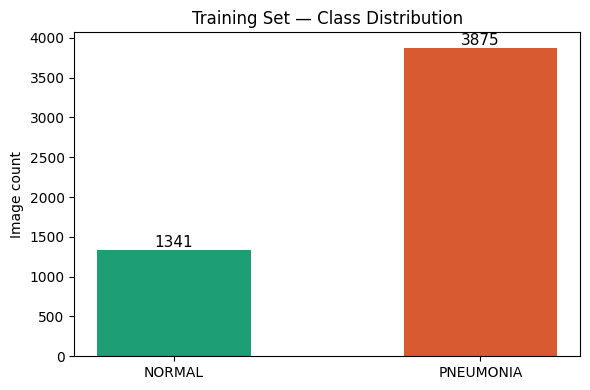

Imbalance ratio: 2.89


In [24]:
#visualizing class impbalance
counts = [sum(1 for _ , l in train_set.samples if l == i) for i in range (NUM_CLASSES)]

plt.figure(figsize=(6,4))
bars = plt.bar(CLASS_NAMES, counts, color=["#1D9E75", "#D85A30"], width=0.5)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30, str(count), ha="center", fontsize=11)
plt.title("Training Set — Class Distribution")
plt.ylabel("Image count")
plt.tight_layout()
plt.show()
print(f"Imbalance ratio: {max(counts)/min(counts):.2f}")



In [25]:
#model building

def build_model():
    model = models.resnet50(weights = models.ResNet50_Weights.DEFAULT)
    
    #freezing all the layers
    for params in model.parameters():
        params.requires_grad = False 
        
    #unfreezing the last  blocks for fine-tuning
        
    for params in model.layer4.parameters():
        params.requires_grad = True
        
        
    #replacing the last fully connected layer according to our use 
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES )
    )
    
    return model.to(DEVICE)

model = build_model()
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total:,}")
print(f"Trainable params : {trainable:,}  ({100*trainable/total:.1f}%)")
print(f"Frozen params    : {total-trainable:,}  ({100*(total-trainable)/total:.1f}%)")

Total params     : 24,033,090
Trainable params : 15,489,794  (64.5%)
Frozen params    : 8,543,296  (35.5%)


In [26]:
# #trainng loop

criterion = nn.CrossEntropyLoss(weight = torch.tensor([2.89, 1]).to(DEVICE))
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr = LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_loss = float('inf')
best_val_acc= 0.0
best_val_weights = copy.deepcopy(model.state_dict())
history = {"train_loss": [], "val_loss":[], "train_acc": [], "val_acc":[]}
patience = 2
counter = 0

for epoch in range(EPOCHS):
    print(f"\nEpochs: {epoch + 1}/{EPOCHS} | LR= {scheduler.get_last_lr()[0]: .2e}")
    
    for phase, loader in [("train", train_loader), ("val", val_loader)]:
        model.train() if phase == "train" else model.eval()
        running_loss , correct, total = 0.0,0,0
        
        
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == "train"):
                outputs = model(images)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct +=(preds == labels).sum().item()
            total += labels.size(0)
            
        ep_loss = running_loss/total
        ep_acc = correct/total
        history[f"{phase}_loss"].append(ep_loss)
        history[f"{phase}_acc"].append(ep_acc)
        print(f"{phase.upper():5s}  Loss:{ep_loss: .4f}  Acc:{ep_acc:.4f}")

        if phase == "val":
            if ep_loss < best_val_loss:
                best_val_loss = ep_loss   
                best_val_acc = ep_acc
                best_val_weights = copy.deepcopy(model.state_dict())
                torch.save(best_val_weights, MODEL_PTH)
                print(f"Best model saved (val_loss = {best_val_loss:.4f}, val_acc = {best_val_acc:.4f})")
                counter = 0
            else:
                counter += 1
                
    if counter >= patience:
        print("Stopping Early")
        break
    
    scheduler.step()

model.load_state_dict(best_val_weights)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")
        
     
    


Epochs: 1/10 | LR=  1.00e-04
TRAIN  Loss: 0.3280  Acc:0.8823
VAL    Loss: 0.5451  Acc:0.8125
Best model saved (val_loss = 0.5451, val_acc = 0.8125)

Epochs: 2/10 | LR=  9.76e-05
TRAIN  Loss: 0.1501  Acc:0.9415
VAL    Loss: 0.3137  Acc:0.8750
Best model saved (val_loss = 0.3137, val_acc = 0.8750)

Epochs: 3/10 | LR=  9.05e-05
TRAIN  Loss: 0.1220  Acc:0.9548
VAL    Loss: 0.2915  Acc:0.8750
Best model saved (val_loss = 0.2915, val_acc = 0.8750)

Epochs: 4/10 | LR=  7.96e-05
TRAIN  Loss: 0.1144  Acc:0.9590
VAL    Loss: 0.1971  Acc:0.8750
Best model saved (val_loss = 0.1971, val_acc = 0.8750)

Epochs: 5/10 | LR=  6.58e-05
TRAIN  Loss: 0.1120  Acc:0.9572
VAL    Loss: 0.1261  Acc:1.0000
Best model saved (val_loss = 0.1261, val_acc = 1.0000)

Epochs: 6/10 | LR=  5.05e-05
TRAIN  Loss: 0.0896  Acc:0.9686
VAL    Loss: 0.2828  Acc:0.8750

Epochs: 7/10 | LR=  3.52e-05
TRAIN  Loss: 0.0835  Acc:0.9716
VAL    Loss: 0.1682  Acc:0.9375
Stopping Early

Best validation accuracy: 1.0000


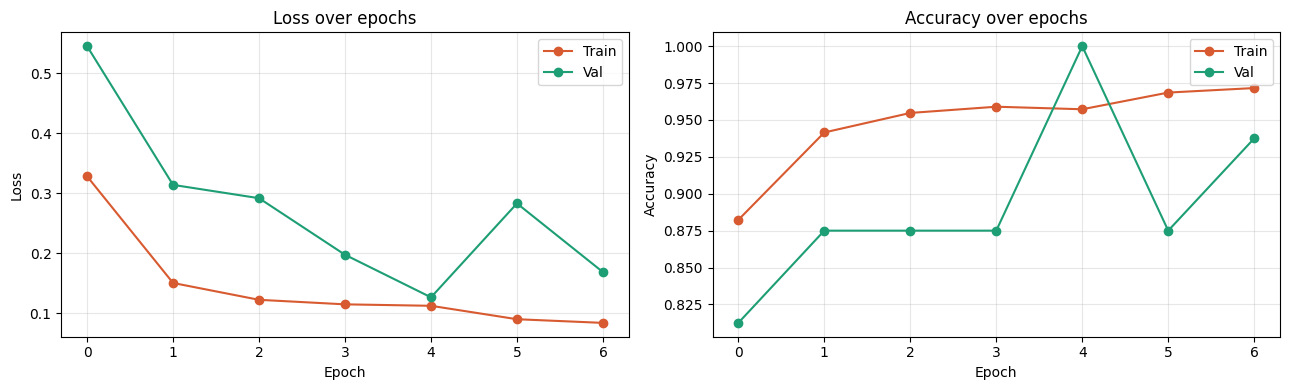

Saved: training_curves.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], marker="o", label="Train", color="#D85A30")
axes[0].plot(history["val_loss"],   marker="o", label="Val",   color="#1D9E75")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], marker="o", label="Train", color="#D85A30")
axes[1].plot(history["val_acc"],   marker="o", label="Val",   color="#1D9E75")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WEIGHT_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Saved: training_curves.png")

Classification Report
              precision    recall  f1-score   support

      NORMAL       0.90      0.98      0.94      1341
   PNEUMONIA       0.99      0.96      0.98      3875

    accuracy                           0.97      5216
   macro avg       0.95      0.97      0.96      5216
weighted avg       0.97      0.97      0.97      5216



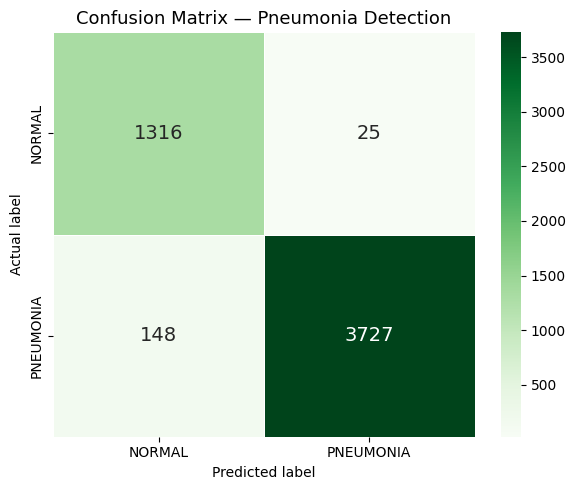

Saved: confusion_matrix.png


In [29]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(DEVICE))
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Classification Report")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, annot_kws={"size": 14})
plt.title("Confusion Matrix — Pneumonia Detection", fontsize=13)
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig(os.path.join(WEIGHT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

In [30]:

with open(MODEL_PKL, "wb") as f:
    pickle.dump(model, f)
print(f"Pickle saved : {MODEL_PKL}")

meta = {
    "class_names" : CLASS_NAMES,
    "input_size"  : (224, 224),
    "model_name"  : "resnet50",
    "best_val_acc": round(best_val_acc, 4),
    "num_classes" : NUM_CLASSES,
}
meta_path = os.path.join(WEIGHT_DIR, "model_meta.pkl")
with open(meta_path, "wb") as f:
    pickle.dump(meta, f)
print(f"Meta saved   : {meta_path}")

Pickle saved : f:\Naman\medvision_ai\models\weights\resnet50_pneumonia.pkl
Meta saved   : f:\Naman\medvision_ai\models\weights\model_meta.pkl
